In [1]:
import pandas as pd
import numpy as np
import sklearn
import nltk

print("Everything is working!")
print("Python environment is ready.")
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

Everything is working!
Python environment is ready.
Pandas version: 3.0.6
Scikit-learn version: 1.9.1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_;",
    "char_freq_(",
    "char_freq_[",
    "char_freq_!",
    "char_freq_$",
    "char_freq_#",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    "spam"
]

In [6]:
data_path = "../data/spambase.data"

df = pd.read_csv(
    data_path,
    header=None,
    names=columns
)

df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [7]:
print("Dataset shape:", df.shape)

Dataset shape: (4601, 58)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [9]:
df["spam"].value_counts()

spam
0    2788
1    1813
Name: count, dtype: int64

In [10]:
df["spam"].value_counts(normalize=True) * 100

spam
0    60.595523
1    39.404477
Name: proportion, dtype: float64

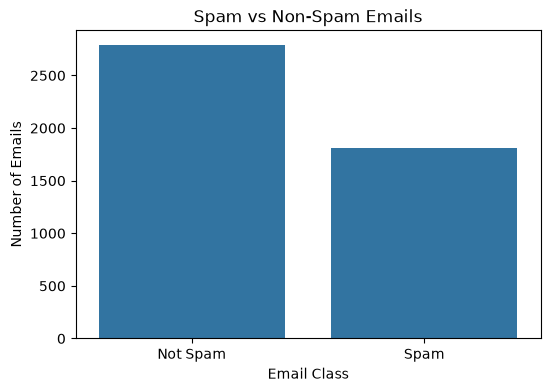

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(x="spam", data=df)

plt.title("Spam vs Non-Spam Emails")
plt.xlabel("Email Class")
plt.ylabel("Number of Emails")
plt.xticks([0, 1], ["Not Spam", "Spam"])

plt.show()

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(391)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213015,1.290575,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.280656,0.504143,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312223,0.672513,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.095901,0.273824,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090067,0.278616,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.000,0.000,0.160,18.180


In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.duplicated().sum()

np.int64(391)

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213015,1.290575,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.280656,0.504143,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312223,0.672513,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.095901,0.273824,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090067,0.278616,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.000,0.000,0.160,18.180


In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.duplicated().sum()


np.int64(391)

In [20]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 391


In [21]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_label_check = (
    duplicate_rows
    .groupby(columns[:-1])["spam"]
    .nunique()
)

print("Duplicate groups with conflicting labels:",
      (duplicate_label_check > 1).sum())

Duplicate groups with conflicting labels: 0


In [22]:
print("Rows before removing duplicates:", len(df))

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", len(df))

Rows before removing duplicates: 4601
Rows after removing duplicates: 4210


In [23]:
class_distribution = df["spam"].value_counts()

print(class_distribution)
print()
print("Percentage distribution:")
print(df["spam"].value_counts(normalize=True) * 100)

spam
0    2531
1    1679
Name: count, dtype: int64

Percentage distribution:
spam
0    60.118765
1    39.881235
Name: proportion, dtype: float64


In [24]:
X = df.drop("spam", axis=1)
y = df["spam"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4210, 57)
y shape: (4210,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3368
Testing samples: 842


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (3368, 57)
Testing data shape: (842, 57)


In [27]:
X = df.drop("spam", axis=1)
y = df["spam"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4210, 57)
y shape: (4210,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3368
Testing samples: 842


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (3368, 57)
Testing data shape: (842, 57)


In [30]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [31]:
y_pred_nb = nb_model.predict(X_test_scaled)

print("Predictions generated:", len(y_pred_nb))

Predictions generated: 842


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print("-------------------")
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-score : {f1_nb:.4f}")

Naive Bayes Results
-------------------
Accuracy : 0.8290
Precision: 0.7143
Recall   : 0.9524
F1-score : 0.8163


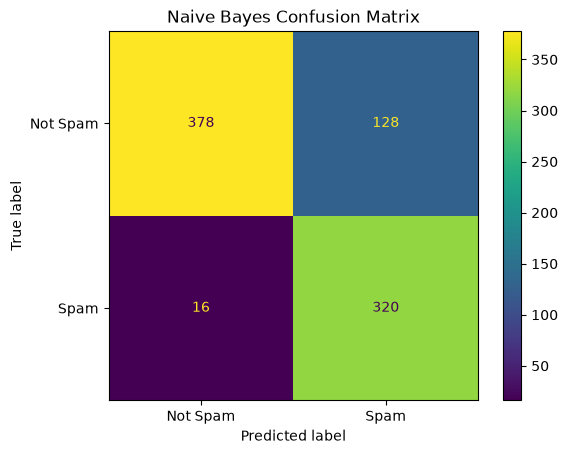

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Not Spam", "Spam"]
)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [35]:
y_pred_lr = lr_model.predict(X_test_scaled)

print("Predictions generated:", len(y_pred_lr))

Predictions generated: 842


In [36]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.9347
Precision: 0.9297
Recall   : 0.9048
F1-score : 0.9170


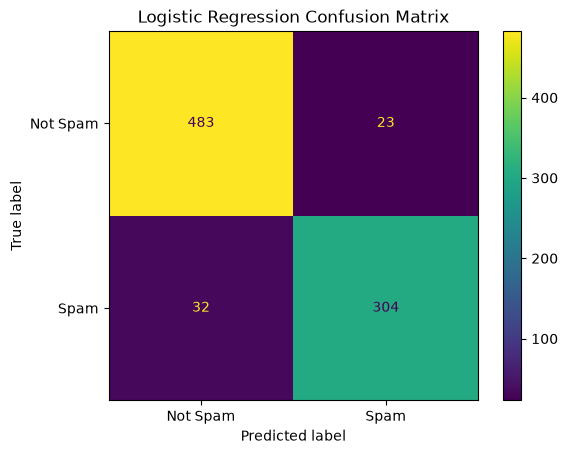

In [37]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Not Spam", "Spam"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [38]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [39]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("Predictions generated:", len(y_pred_svm))

Predictions generated: 842


In [40]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("-----------")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")

SVM Results
-----------
Accuracy : 0.9323
Precision: 0.9319
Recall   : 0.8958
F1-score : 0.9135


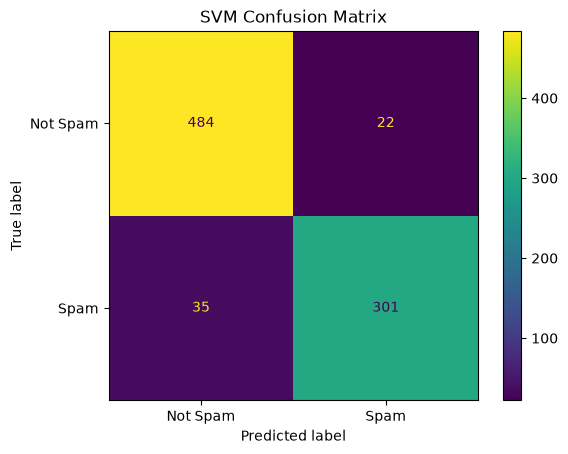

In [41]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Not Spam", "Spam"]
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [42]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr,
        accuracy_svm
    ],
    "Precision": [
        precision_nb,
        precision_lr,
        precision_svm
    ],
    "Recall": [
        recall_nb,
        recall_lr,
        recall_svm
    ],
    "F1-score": [
        f1_nb,
        f1_lr,
        f1_svm
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.828979,0.714286,0.952381,0.816327
1,Logistic Regression,0.934679,0.929664,0.904762,0.917044
2,SVM,0.932304,0.931889,0.895833,0.913505


In [43]:
results_display = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-score"]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2).astype(str) + "%"

results_display

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,82.9%,71.43%,95.24%,81.63%
1,Logistic Regression,93.47%,92.97%,90.48%,91.7%
2,SVM,93.23%,93.19%,89.58%,91.35%


In [44]:
import joblib

In [45]:
joblib.dump(nb_model, "../models/naive_bayes_model.pkl")
joblib.dump(lr_model, "../models/logistic_regression_model.pkl")
joblib.dump(svm_model, "../models/svm_model.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

print("Models and scaler saved successfully!")

Models and scaler saved successfully!


# Email Spam Detection Using Machine Learning

## Project Overview

This project develops a machine learning pipeline for classifying emails as spam or non-spam using the UCI Spambase dataset.

The workflow includes:
- Exploratory Data Analysis
- Data quality checking
- Duplicate removal
- Train-test splitting
- Feature standardization
- Naive Bayes classification
- Logistic Regression classification
- Support Vector Machine classification
- Model evaluation using Accuracy, Precision, Recall and F1-score
- Confusion matrix analysis
- Model persistence using Joblib

In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
26,word_freq_george,-4.015556,4.015556
24,word_freq_hp,-2.484120,2.484120
45,word_freq_edu,-1.336849,1.336849
52,char_freq_$,1.228077,1.228077
41,word_freq_meeting,-1.222367,1.222367
40,word_freq_cs,-1.189312,1.189312
28,word_freq_lab,-1.105883,1.105883
6,word_freq_remove,1.047907,1.047907
55,capital_run_length_longest,1.046090,1.046090
25,word_freq_hpl,-0.985131,0.985131


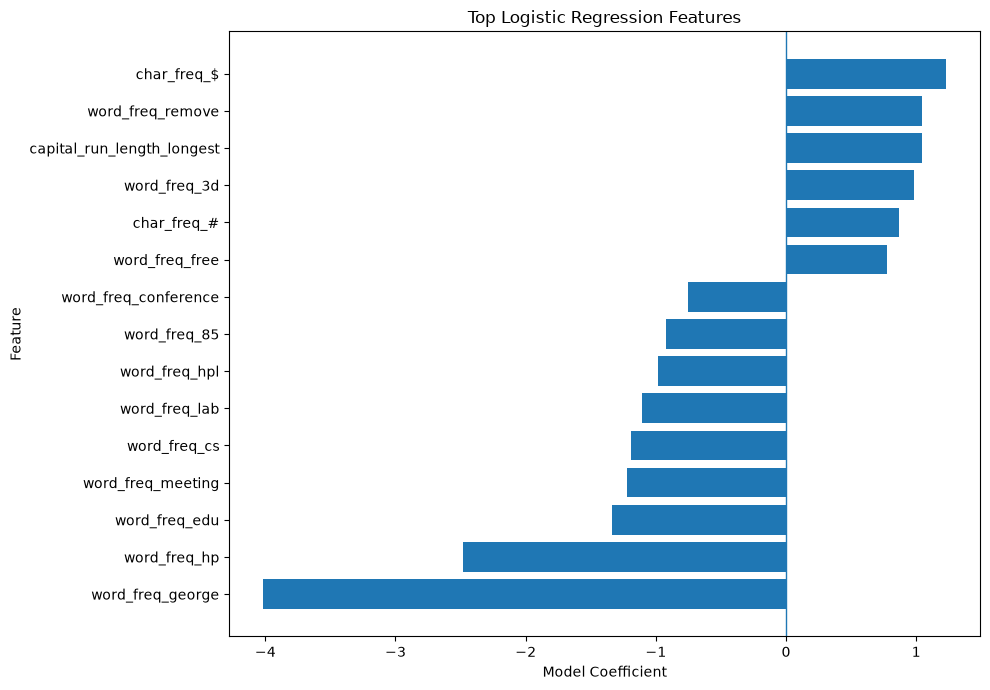

In [48]:
top_features = feature_importance.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)
plt.title("Top Logistic Regression Features")
plt.xlabel("Model Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [49]:
final_results = results.copy()

final_results["Accuracy"] = (
    final_results["Accuracy"] * 100
).round(2)

final_results["Precision"] = (
    final_results["Precision"] * 100
).round(2)

final_results["Recall"] = (
    final_results["Recall"] * 100
).round(2)

final_results["F1-score"] = (
    final_results["F1-score"] * 100
).round(2)

final_results

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,82.90,71.43,95.24,81.63
1,Logistic Regression,93.47,92.97,90.48,91.70
2,SVM,93.23,93.19,89.58,91.35
